In [ ]:

from google.colab import drive
drive.mount('/content/drive')
!unzip "/content/drive/MyDrive/archive.zip" -d "/content/dataset"
import os
print("لیست پوشه‌های ایجاد شده:")
print(os.listdir("/content/dataset"))

Streaming output truncated to the last 5000 lines.
  inflating: /content/dataset/train/5/00005_00053_00012.png  
  inflating: /content/dataset/train/5/00005_00053_00013.png  
  inflating: /content/dataset/train/5/00005_00053_00014.png  
  inflating: /content/dataset/train/5/00005_00053_00015.png  
  inflating: /content/dataset/train/5/00005_00053_00016.png  
  inflating: /content/dataset/train/5/00005_00053_00017.png  
  inflating: /content/dataset/train/5/00005_00053_00018.png  
  inflating: /content/dataset/train/5/00005_00053_00019.png  
  inflating: /content/dataset/train/5/00005_00053_00020.png  
  inflating: /content/dataset/train/5/00005_00053_00021.png  
  inflating: /content/dataset/train/5/00005_00053_00022.png  
  inflating: /content/dataset/train/5/00005_00053_00023.png  
  inflating: /content/dataset/train/5/00005_00053_00024.png  
  inflating: /content/dataset/train/5/00005_00053_00025.png  
  inflating: /content/dataset/train/5/00005_00053_00026.png  
  inflating: /conte

In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import tensorflow as tf
import os
from PIL import Image
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
data_dir = '/content/dataset'
train_path = '/content/dataset/Train'
test_path = '/content/dataset/Test'
IMG_HEIGHT = 30
IMG_WIDTH = 30
CHANNELS = 3
NUM_CATEGORIES = 43

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
import os
import cv2
import numpy as np
from PIL import Image
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

image_data = []
image_labels = []


for i in range(NUM_CATEGORIES):
    path = os.path.join(train_path, str(i))
    images = os.listdir(path)

    for img_name in images:
        try:

            img_path = os.path.join(path, img_name)
            image = cv2.imread(img_path)


            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            image = cv2.resize(image, (IMG_WIDTH, IMG_HEIGHT))

            image_data.append(image)
            image_labels.append(i)
        except Exception as e:
            print(f"Error loading image {img_name}: {e}")

X = np.array(image_data)
y = np.array(image_labels)
X = X.astype('float32') / 255.0


X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)
y_train = to_categorical(y_train, NUM_CATEGORIES)
y_val = to_categorical(y_val, NUM_CATEGORIES)

print(f"تعداد کل تصاویر: {len(X)}")

تعداد کل تصاویر: 39209


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPool2D, Dense, Flatten, Dropout


model = Sequential()
model.add(Conv2D(filters=32, kernel_size=(5,5), activation='relu', input_shape=(IMG_HEIGHT, IMG_WIDTH, CHANNELS)))
model.add(Conv2D(filters=32, kernel_size=(5,5), activation='relu'))
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Dropout(rate=0.25))

model.add(Conv2D(filters=64, kernel_size=(3, 3), activation='relu'))
model.add(Conv2D(filters=64, kernel_size=(3, 3), activation='relu'))
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Dropout(rate=0.25))

# Flatten و Dense
model.add(Flatten())
model.add(Dense(256, activation='relu'))
model.add(Dropout(rate=0.5))
model.add(Dense(NUM_CATEGORIES, activation='softmax')) # خروجی ۴۳ کلاس

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 22, 22, 32)     │        25,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 11, 11, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 11, 11, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 9, 9, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 3, 3, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 3, 3, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       147,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 43)             │        11,051 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 242,251 (946.29 KB)

 Trainable params: 242,251 (946.29 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:

epochs = 15

history = model.fit(X_train, y_train, batch_size=32, epochs=epochs, validation_data=(X_val, y_val))

Epoch 1/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 141s 140ms/step - accuracy: 0.3754 - loss: 2.2944 - val_accuracy: 0.9606 - val_loss: 0.1623
Epoch 2/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 134s 137ms/step - accuracy: 0.9150 - loss: 0.2737 - val_accuracy: 0.9772 - val_loss: 0.0899
Epoch 3/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 138s 140ms/step - accuracy: 0.9559 - loss: 0.1493 - val_accuracy: 0.9899 - val_loss: 0.0442
Epoch 4/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 142s 140ms/step - accuracy: 0.9647 - loss: 0.1134 - val_accuracy: 0.9923 - val_loss: 0.0317
Epoch 5/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 142s 141ms/step - accuracy: 0.9713 - loss: 0.0942 - val_accuracy: 0.9922 - val_loss: 0.0282
Epoch 6/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 140s 138ms/step - accuracy: 0.9756 - loss: 0.0780 - val_accuracy: 0.9916 - val_loss: 0.0323
Epoch 7/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 134s 137ms/step - accuracy: 0.9785 - loss: 0.0710 - val_accuracy: 0.9895 - val_loss: 0.0384
Epoch 8/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 135s 138ms/step - accuracy: 0.9791 -

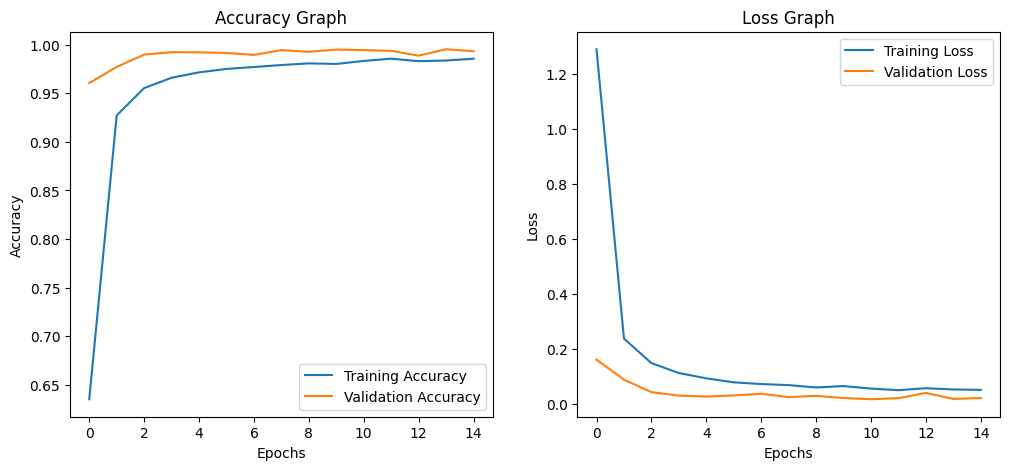

In [ ]:

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Graph')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Graph')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [ ]:

model.save("traffic_classifier.h5")
print("Model Saved!")

Model Saved!


246/246 ━━━━━━━━━━━━━━━━━━━━ 8s 34ms/step


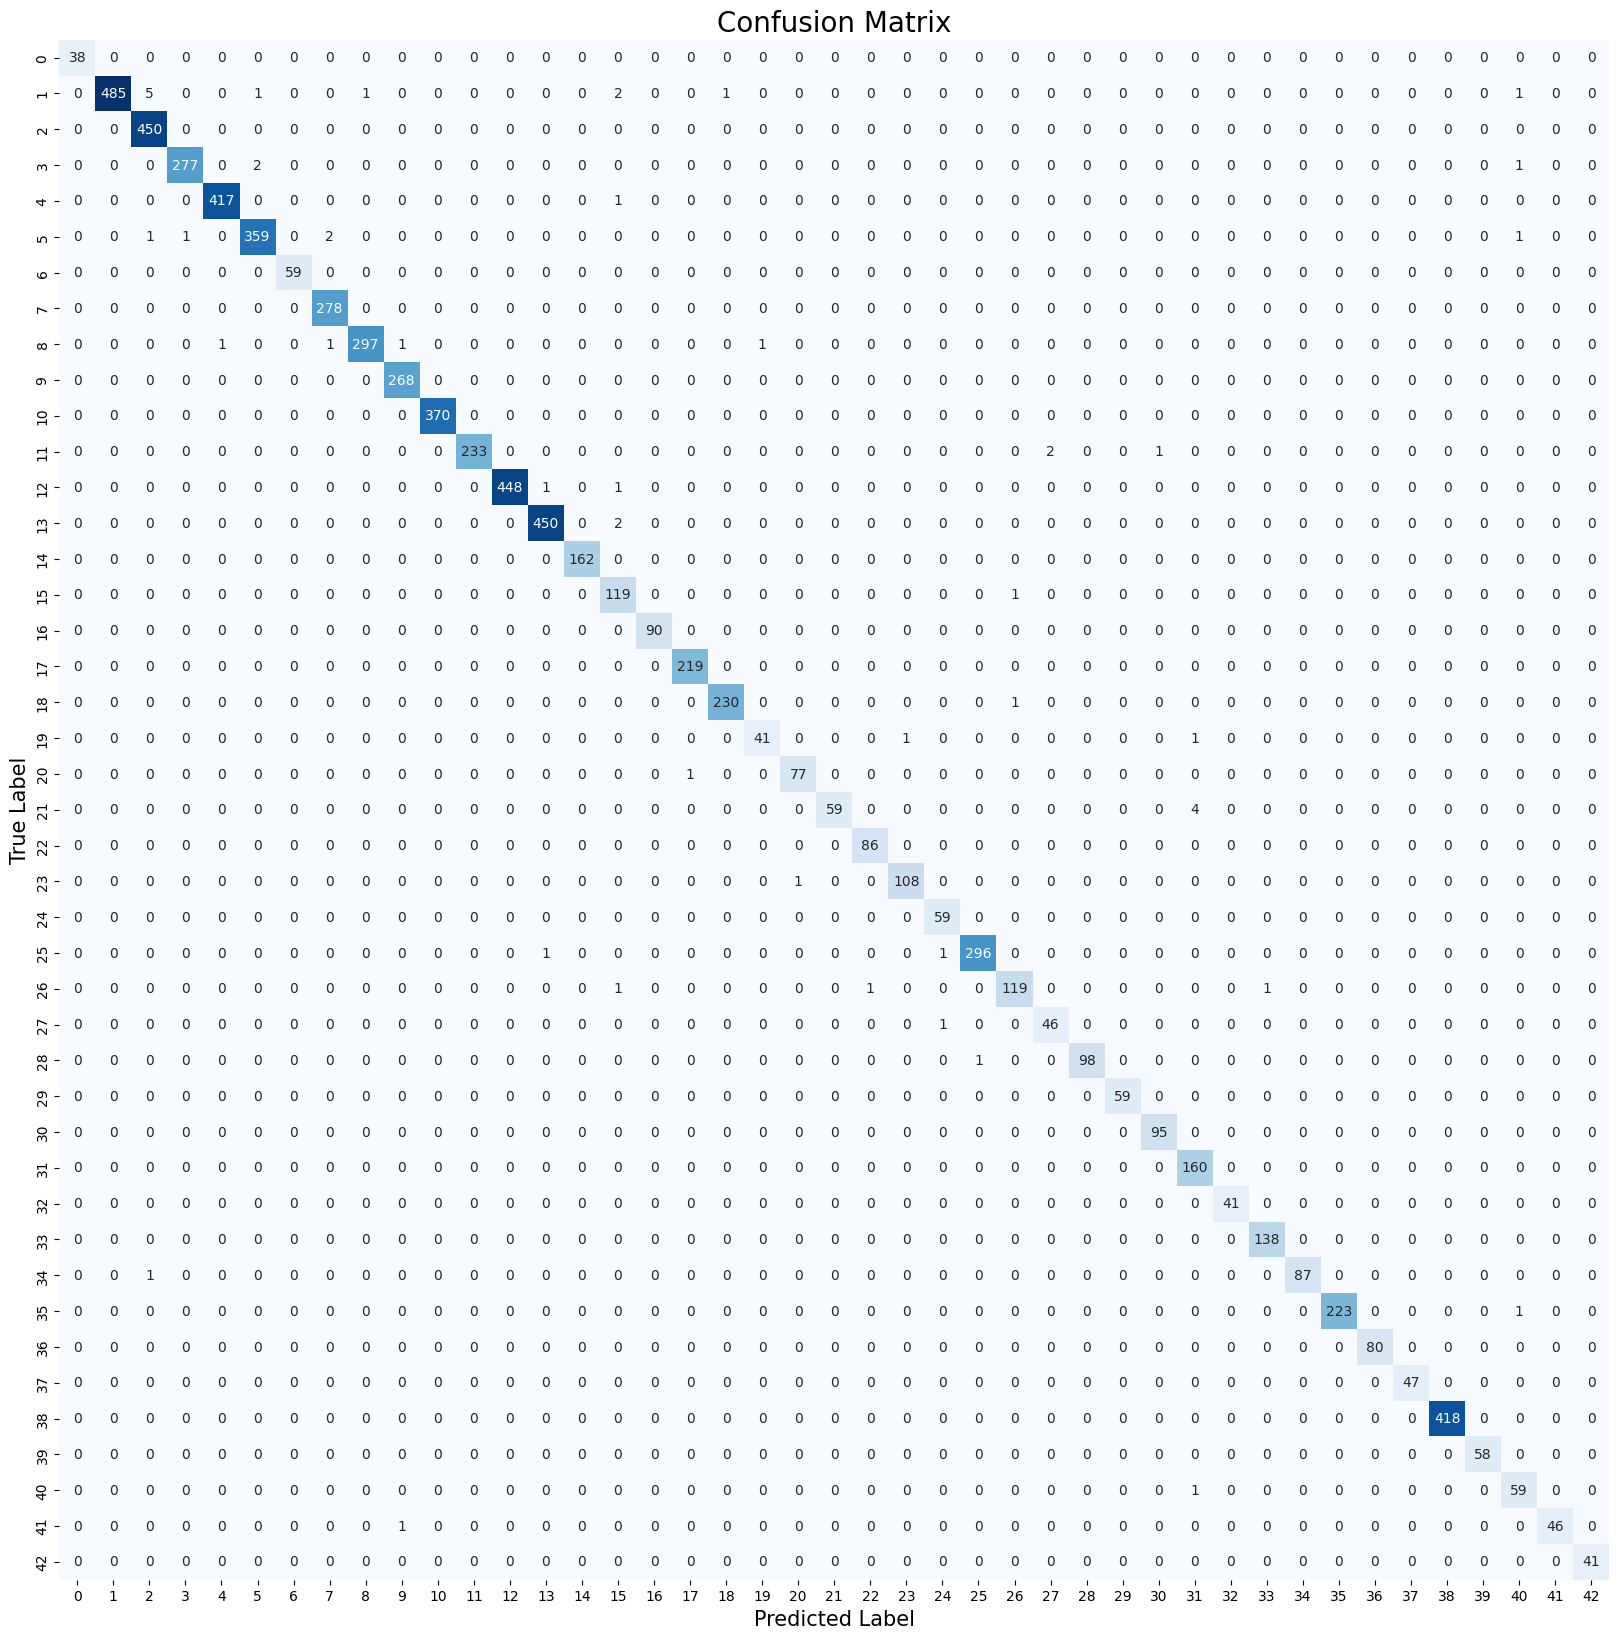


Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        38
           1       1.00      0.98      0.99       496
           2       0.98      1.00      0.99       450
           3       1.00      0.99      0.99       280
           4       1.00      1.00      1.00       418
           5       0.99      0.99      0.99       364
           6       1.00      1.00      1.00        59
           7       0.99      1.00      0.99       278
           8       1.00      0.99      0.99       301
           9       0.99      1.00      1.00       268
          10       1.00      1.00      1.00       370
          11       1.00      0.99      0.99       236
          12       1.00      1.00      1.00       450
          13       1.00      1.00      1.00       452
          14       1.00      1.00      1.00       162
          15       0.94      0.99      0.97       120
          16       1.00      1.00      1.00        90
  

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

pred_probabilities = model.predict(X_val)
pred_classes = np.argmax(pred_probabilities, axis=1)
true_classes = np.argmax(y_val, axis=1)

cm = confusion_matrix(true_classes, pred_classes)

plt.figure(figsize=(20, 20))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix', fontsize=20)
plt.xlabel('Predicted Label', fontsize=15)
plt.ylabel('True Label', fontsize=15)
plt.show()

# (Precision, Recall, F1-Score)
print("\nClassification Report:\n")
print(classification_report(true_classes, pred_classes))

In [ ]:

classes = { 0:'Speed limit (20km/h)', 1:'Speed limit (30km/h)', 2:'Speed limit (50km/h)',
            3:'Speed limit (60km/h)', 4:'Speed limit (70km/h)', 5:'Speed limit (80km/h)',
            6:'End of speed limit (80km/h)', 7:'Speed limit (100km/h)', 8:'Speed limit (120km/h)',
            9:'No passing', 10:'No passing veh over 3.5 tons', 11:'Right-of-way at intersection',
            12:'Priority road', 13:'Yield', 14:'Stop', 15:'No vehicles',
            16:'Veh > 3.5 tons prohibited', 17:'No entry', 18:'General caution',
            19:'Dangerous curve left', 20:'Dangerous curve right', 21:'Double curve',
            22:'Bumpy road', 23:'Slippery road', 24:'Road narrows on the right',
            25:'Road work', 26:'Traffic signals', 27:'Pedestrians', 28:'Children crossing',
            29:'Bicycles crossing', 30:'Beware of ice/snow', 31:'Wild animals crossing',
            32:'End speed + passing limits', 33:'Turn right ahead', 34:'Turn left ahead',
            35:'Ahead only', 36:'Go straight or right', 37:'Go straight or left',
            38:'Keep right', 39:'Keep left', 40:'Roundabout mandatory',
            41:'End of no passing', 42:'End no passing veh > 3.5 tons' }

def predict_traffic_sign(image_path):

    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_pil = Image.fromarray(img)
    img_resized = img_pil.resize((30, 30))
    img_array = np.array(img_resized) / 255.0
    img_array = np.expand_dims(img_array, axis=0)


    pred = model.predict(img_array)
    class_index = np.argmax(pred)
    probability = np.max(pred)
    plt.imshow(img)
    plt.title(f"Prediction: {classes[class_index]} \n Confidence: {probability*100:.2f}%")
    plt.axis('off')
    plt.show()



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


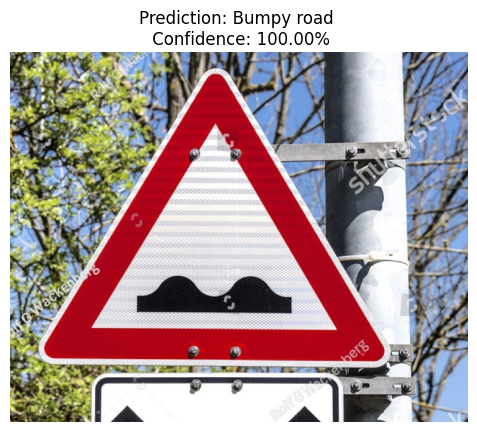

In [ ]:
predict_traffic_sign("m4.jpg")